## Import libraries

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from IPython.display import Image

import os, sys

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)

sns.set_style("whitegrid")
%matplotlib inline


In [2]:
from fmu2ml.analysis.rate_of_change.analyzers import (
    RateOfChangeAnalyzer,
    ImpulseResponseAnalyzer,
    DynamicDataGenerator
)
from fmu2ml.analysis.rate_of_change.visualizers import *


In [ ]:
from raps.config import ConfigManager

SYSTEM_NAME = 'summit'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()


## Define Parameters

In [4]:
N_SAMPLES = 1000
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/data_analysis/io_rate_of_change'
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_STEPS = 20
DATA_TYPE = 'combined'  # 'step', 'ramp', 'varying', 'combined'

# Input ranges
INPUT_RANGES = {
    'Q_flow': (config.get('MIN_POWER'), config.get('MAX_POWER')),    # kW
    'T_Air': (288.15, 308.15),   # K
    'T_ext': (283.15, 313.15)    # K
}

# Parallel settings
N_WORKERS = 16
THREADS_PER_WORKER = 1
MEMORY_LIMIT = '64GB'

# Analysis parameters
MAX_LAG = 30
SMOOTH_WINDOW = 5
DT = 1.0  # Time step for derivatives

print(f"System: {SYSTEM_NAME}")
print(f"Data type: {DATA_TYPE}")
print(f"Samples: {N_SAMPLES}")
print(f"Output dir: {OUTPUT_DIR}")

#  Load Configuration
num_cdus = config.get('NUM_CDUS', 49)

# Add analysis-specific settings
config['derivative'] = {'dt': DT, 'smooth_window': SMOOTH_WINDOW}
config['impulse_detection'] = {
    'threshold_percentile': 90,
    'min_change_fraction': 0.1,
    'min_duration': 10
}
config['response_analysis'] = {
    'pre_window': 30,
    'post_window': 60
}

print(f"Number of CDUs: {num_cdus}")
print(f"Configuration loaded")


System: summit
Data type: combined
Samples: 1000
Output dir: ../results/summit/data_analysis/io_rate_of_change
Number of CDUs: 257
Configuration loaded


In [5]:


# Initialize Components
config_for_components = {k: v for k, v in config.items() if k != 'system_name'}

# Data generator
data_generator = DynamicDataGenerator(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    **config_for_components
)

# Analyzers
rate_analyzer = RateOfChangeAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    **config_for_components
)

impulse_analyzer = ImpulseResponseAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    **config_for_components
)

print("Components initialized")


2026-01-30 07:03:16 - fmu2ml.analysis.rate_of_change.analyzers.dynamic_data_generator - INFO - DynamicDataGenerator initialized for system: summit
2026-01-30 07:03:16 - fmu2ml.analysis.rate_of_change.analyzers.dynamic_data_generator - INFO - Number of CDUs: 257
2026-01-30 07:03:16 - fmu2ml.analysis.rate_of_change.analyzers.dynamic_data_generator - INFO - CDU variation enabled: True
2026-01-30 07:03:16 - fmu2ml.analysis.rate_of_change.analyzers.dynamic_data_generator - INFO - Parallel workers (scenario-level): 16
2026-01-30 07:03:16 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - RateOfChangeAnalyzer initialized for system: summit
2026-01-30 07:03:16 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Number of CDUs: 257
2026-01-30 07:03:16 - fmu2ml.analysis.rate_of_change.analyzers.impulse_response_analyzer - INFO - ImpulseResponseAnalyzer initialized for system: summit
2026-01-30 07:03:16 - fmu2ml.analysis.rate_of_change.analyzers.im

Components initialized


## Generate and Prepare Data

In [6]:
# Generate Dynamic Data
print(f"Generating {DATA_TYPE} data...")

if DATA_TYPE == 'step':
    data = data_generator.generate_step_response_data(
        n_steps=N_STEPS,
        step_duration=120,
        input_ranges=INPUT_RANGES
    )
elif DATA_TYPE == 'ramp':
    data = data_generator.generate_ramp_data(
        n_ramps=N_STEPS,
        ramp_duration=60,
        hold_duration=60,
        input_ranges=INPUT_RANGES
    )
elif DATA_TYPE == 'varying':
    data = data_generator.generate_varying_rate_data(
        n_samples=N_SAMPLES,
        input_ranges=INPUT_RANGES
    )
else:  # combined
    data = data_generator.generate_combined_dynamic_data(
        n_samples=N_SAMPLES,
        input_ranges=INPUT_RANGES
    )

print(f"Data shape: {data.shape}")

# Save data
data_file = os.path.join(OUTPUT_DIR, 'dynamic_data.parquet')
data.to_parquet(data_file)
print(f"Data saved to: {data_file}")


2026-01-30 07:03:17 - fmu2ml.analysis.rate_of_change.analyzers.dynamic_data_generator - INFO - Generating combined dynamic data with 3600 total samples...


Generating combined data...


2026-01-30 07:04:24 - fmu2ml.analysis.rate_of_change.analyzers.dynamic_data_generator - INFO - Created combined dynamic time-series with 3600 steps
2026-01-30 07:04:25 - fmu2ml.analysis.rate_of_change.analyzers.dynamic_data_generator - INFO - Running sequential FMU simulation with 3600 steps...
2026-01-30 07:04:25 - fmu2ml.analysis.rate_of_change.analyzers.dynamic_data_generator - INFO - Note: Sequential execution maintains state causality across time steps


Initializing FMU...


2026-01-30 07:04:52 - fmu2ml.simulation.fmu_simulator - INFO - ✓ FMU simulator initialized for summit
2026-01-30 07:04:52 - fmu2ml.simulation.fmu_simulator - INFO - NUM_CDUS: 257


RK-method: sdirk34hw
Local extrapolation
FSAL
Continuous extension
Initializing FMU...


2026-01-30 07:05:19 - fmu2ml.simulation.fmu_simulator - INFO - FMU reset to initial state
2026-01-30 07:05:19 - fmu2ml.simulation.fmu_simulator - INFO - Starting stabilization (max 3 hours)...


RK-method: sdirk34hw
Local extrapolation
FSAL
Continuous extension


2026-01-30 07:44:53 - fmu2ml.simulation.fmu_simulator - INFO - Steady state reached at 2.15 hours
2026-01-30 07:44:54 - fmu2ml.simulation.fmu_simulator - INFO - Running operational simulation for 3600 steps...
2026-01-30 11:16:41 - fmu2ml.simulation.fmu_simulator - INFO - Progress: 3600/3600 steps (100.0%)
2026-01-30 11:16:41 - fmu2ml.simulation.fmu_simulator - INFO - Simulation complete
2026-01-30 11:16:45 - fmu2ml.analysis.rate_of_change.analyzers.dynamic_data_generator - INFO - Simulation completed: 3600 samples generated
2026-01-30 11:16:45 - fmu2ml.simulation.fmu_simulator - INFO - FMU resources cleaned up


Data shape: (3600, 6430)
Data saved to: ../results/summit/data_analysis/io_rate_of_change/dynamic_data.parquet


In [7]:
# Prepare Data
prepared_data = rate_analyzer.prepare_data(data)
print(f"Data prepared. Shape: {prepared_data['inputs']['Q_flow'].shape}")
print(f"Input variables: {rate_analyzer.input_vars}")
print(f"Output variables (first 5): {rate_analyzer.output_vars[:5]}")


2026-01-30 11:16:47 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Preparing data for rate of change analysis...
2026-01-30 11:16:49 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Data prepared: 3 inputs, 14 outputs


Data prepared. Shape: (3600, 257)
Input variables: ['Q_flow', 'T_Air', 'T_ext']
Output variables (first 5): ['V_flow_prim_GPM', 'V_flow_sec_GPM', 'W_flow_CDUP_kW', 'T_prim_s_C', 'T_prim_r_C']


In [9]:

# Compute Derivatives
print("Computing temporal derivatives...")
derivatives_data = rate_analyzer.compute_derivatives(
    prepared_data,
    dt=DT,
    smooth_window=SMOOTH_WINDOW
)

print(f"Derivatives computed. Shape: {derivatives_data['inputs']['Q_flow'].shape}")



2026-01-30 11:22:16 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Computing temporal derivatives...
2026-01-30 11:22:16 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Computed derivatives for 6 inputs, 28 outputs


Computing temporal derivatives...
Derivatives computed. Shape: (3599, 257)


In [10]:
derivatives_data['inputs'].keys()

dict_keys(['Q_flow', 'Q_flow_level', 'T_Air', 'T_Air_level', 'T_ext', 'T_ext_level'])

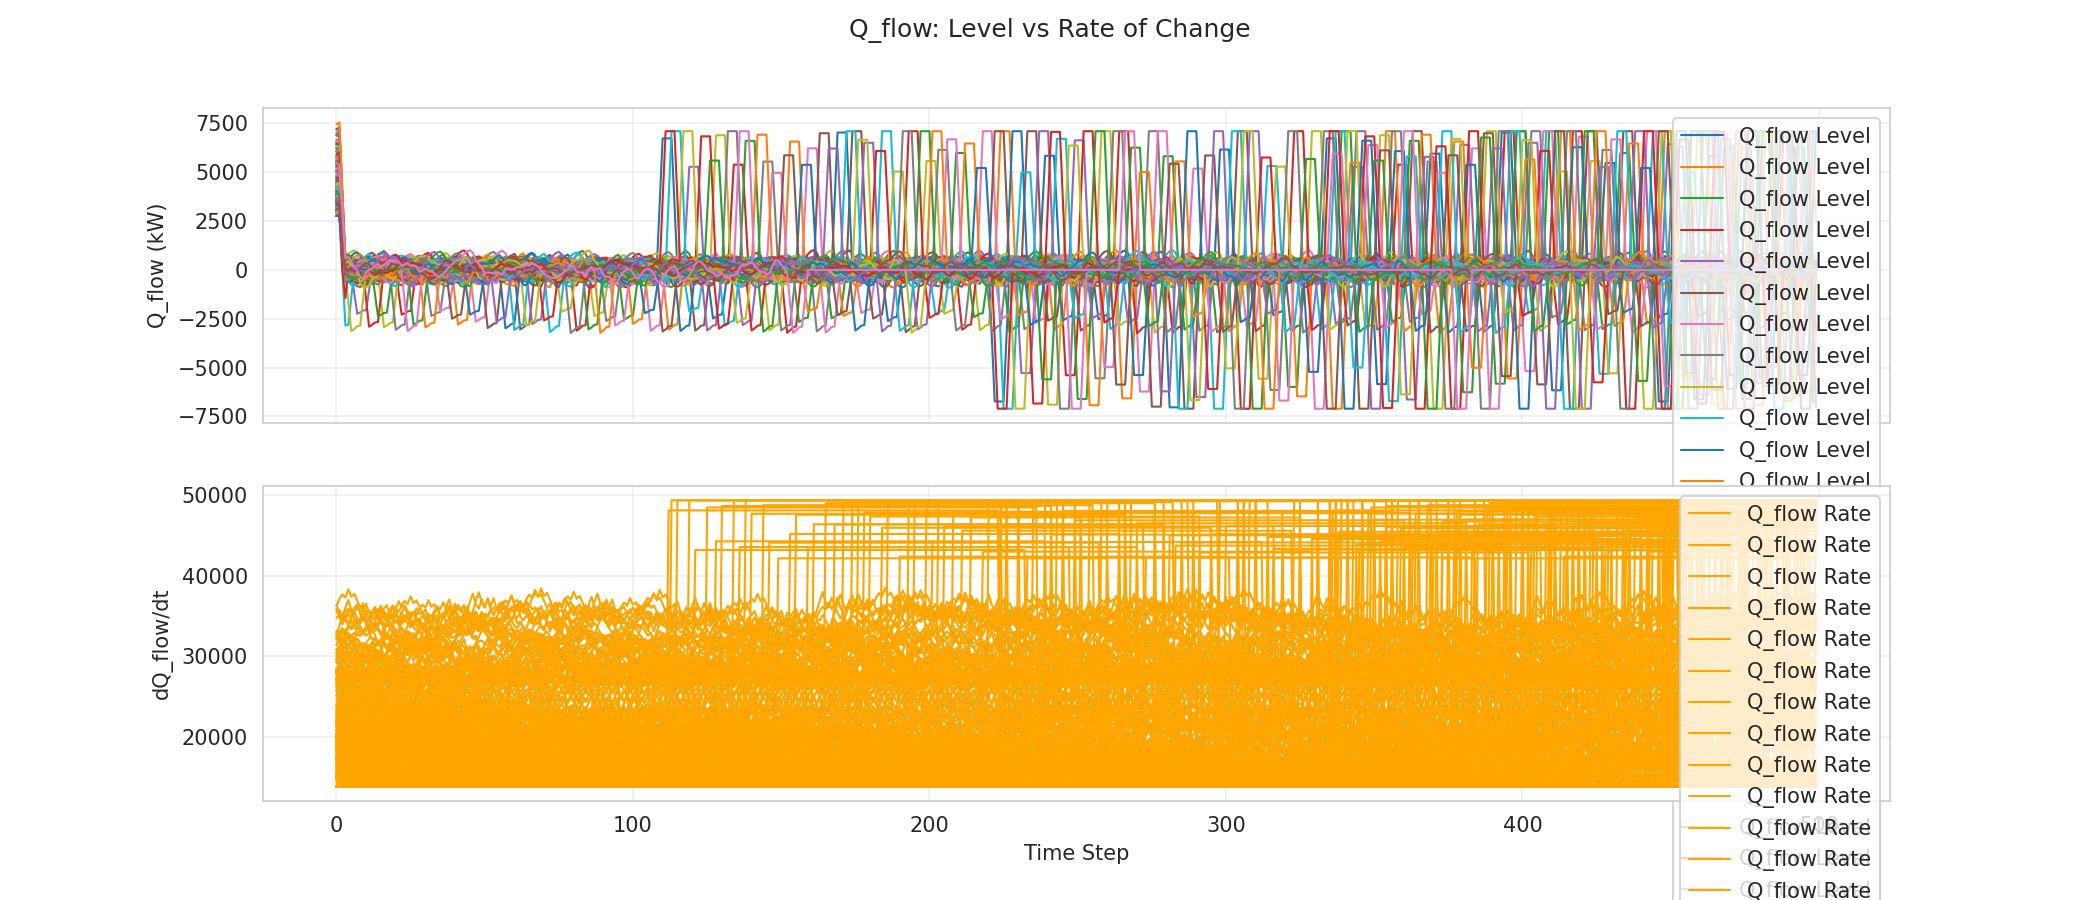

In [11]:
# Visualize Derivatives
# Plot example: Q_flow level and rate
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

sample_range = slice(0, 500)
axes[0].plot(derivatives_data['inputs']['Q_flow'][sample_range], label='Q_flow Level', linewidth=1)
axes[0].set_ylabel('Q_flow (kW)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(derivatives_data['inputs']['Q_flow_level'][sample_range], label='Q_flow Rate', 
             color='orange', linewidth=1)
axes[1].set_ylabel('dQ_flow/dt')
axes[1].set_xlabel('Time Step')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Q_flow: Level vs Rate of Change')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'qflow_level_rate_example.png'), dpi=150)
Image(filename=os.path.join(OUTPUT_DIR,'qflow_level_rate_example.png'))


## 1. Level vs Rate Effect Analysis

In [12]:
print("Analyzing level vs rate effects...")
level_rate_df = rate_analyzer.analyze_all_level_rate_effects(derivatives_data)

print(f"\nRelationships analyzed: {len(level_rate_df)}")

# Effect dominance summary
effect_counts = level_rate_df['dominant_effect'].value_counts()
print("\nEffect Dominance:")
print(effect_counts)

# Display top relationships
print("\nTop 10 Rate-Dominant Effects:")
rate_dominant = level_rate_df[level_rate_df['dominant_effect'] == 'rate'].copy()
rate_dominant = rate_dominant.sort_values('rate_strength', ascending=False)
print(rate_dominant.head(10)[['input', 'output', 'level_strength', 'rate_strength',]])


2026-01-30 11:22:22 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Analyzing level vs rate effects for all pairs...
2026-01-30 11:22:22 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Initializing Dask cluster for rate of change analysis...
2026-01-30 11:22:22 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-01-30 11:22:22 - distributed.scheduler - INFO - State start
2026-01-30 11:22:22 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-oc542bb9', purging
2026-01-30 11:22:22 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-vhavzq7w', purging
2026-01-30 11:22:22 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-o_a7nx3j', purging
2026-01-30 11:22:22 - distributed.dis

Analyzing level vs rate effects...


2026-01-30 11:22:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:44229'
2026-01-30 11:22:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34327'
2026-01-30 11:22:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:44837'
2026-01-30 11:22:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33021'
2026-01-30 11:22:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:42235'
2026-01-30 11:22:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38069'
2026-01-30 11:22:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39793'
2026-01-30 11:22:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:36957'
2026-01-30 11:22:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45663'
2026-01-30 11:22:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:32997'
2026-01-30 11:22:22 - distribu


Relationships analyzed: 39

Effect Dominance:
dominant_effect
level    26
rate      7
mixed     6
Name: count, dtype: int64

Top 10 Rate-Dominant Effects:
    input              output  level_strength  rate_strength
37  T_ext  V_flow_prim_GPM_dc        0.042352       0.067403
32  T_ext           T_sec_r_C        0.002863       0.051597
31  T_ext           T_sec_s_C        0.005461       0.050947
28  T_ext      W_flow_CDUP_kW        0.005115       0.050771
36  T_ext        p_sec_r_psig        0.028248       0.037205
35  T_ext        p_sec_s_psig        0.028252       0.037205
26  T_ext     V_flow_prim_GPM        0.002109       0.002586


In [13]:
# Level vs Rate - Detailed Analysis
# Analyze by input
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    input_data = level_rate_df[level_rate_df['input'] == input_var]
    
    print(f"\n{input_var} Analysis:")
    print(f"  Total relationships: {len(input_data)}")
    print(f"  Level-dominant: {(input_data['dominant_effect'] == 'level').sum()}")
    print(f"  Rate-dominant: {(input_data['dominant_effect'] == 'rate').sum()}")
    print(f"  Mixed: {(input_data['dominant_effect'] == 'mixed').sum()}")
    print(f"  Avg level strength: {input_data['level_strength'].mean():.3f}")
    print(f"  Avg rate strength: {input_data['rate_strength'].mean():.3f}")



Q_flow Analysis:
  Total relationships: 13
  Level-dominant: 12
  Rate-dominant: 0
  Mixed: 1
  Avg level strength: 0.304
  Avg rate strength: 0.051

T_Air Analysis:
  Total relationships: 13
  Level-dominant: 9
  Rate-dominant: 0
  Mixed: 4
  Avg level strength: 0.209
  Avg rate strength: 0.049

T_ext Analysis:
  Total relationships: 13
  Level-dominant: 5
  Rate-dominant: 7
  Mixed: 1
  Avg level strength: 0.070
  Avg rate strength: 0.048


## 2. Response Lag Analysis

In [14]:
print("Analyzing response lags...")
lag_df = rate_analyzer.analyze_response_lags(
    prepared_data,
    max_lag=MAX_LAG
)

print(f"\nRelationships analyzed: {len(lag_df)}")
print(f"Average optimal lag: {lag_df['optimal_lag'].mean():.1f} steps")
print(f"Average max correlation: {lag_df['max_correlation'].mean():.3f}")

# Display relationships with significant lags
significant_lags = lag_df[lag_df['optimal_lag'] > 5]
print(f"\nRelationships with lag > 5 steps: {len(significant_lags)}")
print(significant_lags.nlargest(10, 'optimal_lag')[['input', 'output', 'optimal_lag', 'max_correlation']])


2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Analyzing response lags (max_lag=30)...
2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Executing 39 lag analysis tasks...


Analyzing response lags...


2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Computed lag analysis for 39 pairs



Relationships analyzed: 39
Average optimal lag: 3.3 steps
Average max correlation: 0.061

Relationships with lag > 5 steps: 21
     input          output  optimal_lag  max_correlation
1   Q_flow  V_flow_sec_GPM           30         0.941562
2   Q_flow  W_flow_CDUP_kW           30        -0.441399
3   Q_flow      T_prim_s_C           30        -0.320821
4   Q_flow      T_prim_r_C           30        -0.455814
5   Q_flow       T_sec_s_C           30        -0.438565
6   Q_flow       T_sec_r_C           30        -0.420010
7   Q_flow   p_prim_s_psig           30        -0.474741
8   Q_flow   p_prim_r_psig           30        -0.322202
14   T_Air  V_flow_sec_GPM           30        -0.402599
15   T_Air  W_flow_CDUP_kW           30         0.250313


In [15]:
# Response Lag - By Input
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    input_lags = lag_df[lag_df['input'] == input_var]
    
    print(f"\n{input_var} Lag Analysis:")
    print(f"  Avg optimal lag: {input_lags['optimal_lag'].mean():.1f} steps")
    print(f"  Avg max correlation: {input_lags['max_correlation'].mean():.3f}")
    print(f"  Max lag observed: {input_lags['optimal_lag'].max():.0f} steps")



Q_flow Lag Analysis:
  Avg optimal lag: 6.9 steps
  Avg max correlation: -0.007
  Max lag observed: 30 steps

T_Air Lag Analysis:
  Avg optimal lag: 16.2 steps
  Avg max correlation: 0.093
  Max lag observed: 30 steps

T_ext Lag Analysis:
  Avg optimal lag: -13.2 steps
  Avg max correlation: 0.098
  Max lag observed: 30 steps


In [16]:

# Detect Step Changes for Impulse Analysis
print("Detecting step changes...")
impulse_prepared = impulse_analyzer.prepare_data(data)

step_events = impulse_analyzer.detect_step_changes(
    impulse_prepared,
    threshold_percentile=config['impulse_detection']['threshold_percentile'],
    min_change_fraction=config['impulse_detection']['min_change_fraction'],
    min_duration=config['impulse_detection']['min_duration']
)

print(f"\nStep changes detected:")
for input_var, events in step_events.items():
    print(f"  {input_var}: {len(events)} events")


2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.impulse_response_analyzer - INFO - Preparing data for impulse response analysis...
2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.impulse_response_analyzer - INFO - Prepared 3 inputs, 12 outputs
2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.impulse_response_analyzer - INFO - Detecting step changes in inputs...
2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.impulse_response_analyzer - WARNING - No step changes detected in Q_flow
2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.impulse_response_analyzer - WARNING - No step changes detected in T_Air
2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.impulse_response_analyzer - INFO -   T_ext: 8 step changes detected


Detecting step changes...

Step changes detected:
  Q_flow: 0 events
  T_Air: 0 events
  T_ext: 8 events


## 3. Impulse Response Analysis

In [17]:
print("Analyzing impulse responses...")
response_df = impulse_analyzer.analyze_all_responses(
    impulse_prepared,
    step_events,
    pre_window=config['response_analysis']['pre_window'],
    post_window=config['response_analysis']['post_window']
)

print(f"\nResponses analyzed: {len(response_df)}")
print(f"\nResponse characteristics:")
print(f"  Avg rise time: {response_df['rise_time'].mean():.1f} steps")
print(f"  Avg settling time: {response_df['settling_time'].mean():.1f} steps")
print(f"  Avg gain: {response_df['gain'].mean():.4f}")
print(f"  Avg time constant: {response_df['time_constant'].mean():.1f} steps")


2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.impulse_response_analyzer - INFO - Analyzing impulse responses for all input-output pairs...
2026-01-30 11:22:37 - fmu2ml.analysis.rate_of_change.analyzers.impulse_response_analyzer - INFO - Initializing Dask cluster for impulse response analysis...
2026-01-30 11:22:37 - distributed.scheduler - INFO - State start
2026-01-30 11:22:37 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:36275
2026-01-30 11:22:37 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:33033/status
2026-01-30 11:22:37 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40465'
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:46163'


Analyzing impulse responses...


2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38071'
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:36615'
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34909'
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:46679'
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37457'
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34401'
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:36899'
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:46691'
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45753'
2026-01-30 11:22:37 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39609'
2026-01-30 11:22:37 - distribu


Responses analyzed: 96

Response characteristics:
  Avg rise time: 30.2 steps
  Avg settling time: 57.0 steps
  Avg gain: -0.0615
  Avg time constant: 139.1 steps


In [18]:
response_df.columns

Index(['input', 'output', 'step_index', 'step_magnitude', 'step_direction',
       'initial_value', 'final_value', 'output_change', 'gain', 'rise_time',
       'rise_time_90', 'settling_time', 'overshoot_pct', 'time_constant',
       'fit_r2', 'response_order'],
      dtype='object')

In [19]:

# Impulse Response - Detailed Results
# Display sample responses
print("Sample Impulse Responses:")
print(response_df.head(10)[['input', 'output', 'step_index','step_magnitude', 'step_direction',
       'initial_value', 'final_value', 'output_change', 'gain', 'rise_time',
       'rise_time_90', 'settling_time', 'overshoot_pct', 'time_constant',
       'fit_r2', 'response_order']])

# Analyze by input
for input_var in step_events.keys():
    input_responses = response_df[response_df['input'] == input_var]
    
    if not input_responses.empty:
        print(f"\n{input_var} Response Characteristics:")
        print(f"  Avg rise time: {input_responses['rise_time'].mean():.1f} steps")
        print(f"  Avg settling time: {input_responses['settling_time'].mean():.1f} steps")
        print(f"  Avg gain: {input_responses['gain'].mean():.4f}")
        print(f"  Avg overshoot: {input_responses['overshoot_pct'].mean():.1f}%")


Sample Impulse Responses:
   input           output  step_index  step_magnitude step_direction  \
0  T_ext  V_flow_prim_GPM         111        27.00000             up   
1  T_ext  V_flow_prim_GPM         223       -27.00000           down   
2  T_ext  V_flow_prim_GPM         335        27.00000             up   
3  T_ext  V_flow_prim_GPM         447       -27.00000           down   
4  T_ext  V_flow_prim_GPM         559        27.00000             up   
5  T_ext  V_flow_prim_GPM         671       -27.00000           down   
6  T_ext  V_flow_prim_GPM         783        27.00000             up   
7  T_ext  V_flow_prim_GPM         897       -23.71875           down   
8  T_ext   V_flow_sec_GPM         111        27.00000             up   
9  T_ext   V_flow_sec_GPM         223       -27.00000           down   

   initial_value  final_value  output_change      gain  rise_time  \
0      20.197148    20.241583       0.044435  0.001646         23   
1      20.254075    20.301918       0.04784

In [20]:

# Response Summary Statistics
response_summary_df = impulse_analyzer.summarize_response_characteristics(response_df)

print("Response Summary by Input-Output Pair:")
print(response_summary_df.head(10)[['input', 'output', 'n_events', 
                                     'rise_time_mean', 'gain_mean', 
                                     'time_constant_mean']])

# Combined Dynamic Effects Summary
if not level_rate_df.empty and not lag_df.empty:
    print("Creating combined dynamics summary...")
    dynamics_summary = rate_analyzer.summarize_dynamic_effects(level_rate_df, lag_df)
    
    print(f"\nDynamics summary: {len(dynamics_summary)} relationships")
    print("\nSample entries:")
    print(dynamics_summary.head(10)[['input', 'output', 'dominant_effect', 
                                     'level_strength', 'rate_strength', 
                                     'optimal_lag']])


2026-01-30 11:22:45 - fmu2ml.analysis.rate_of_change.analyzers.impulse_response_analyzer - INFO - Creating response characteristics summary...
2026-01-30 11:22:45 - fmu2ml.analysis.rate_of_change.analyzers.rate_of_change_analyzer - INFO - Creating dynamic effects summary...


Response Summary by Input-Output Pair:
   input              output  n_events  rise_time_mean  gain_mean  \
0  T_ext          T_prim_r_C         8          27.875  -0.005994   
1  T_ext          T_prim_s_C         8          20.500   0.035099   
2  T_ext           T_sec_r_C         8          44.000  -0.000710   
3  T_ext           T_sec_s_C         8          40.375  -0.001040   
4  T_ext     V_flow_prim_GPM         8          23.875   0.000141   
5  T_ext  V_flow_prim_GPM_dc         8          21.750  -0.778580   
6  T_ext      V_flow_sec_GPM         8          11.000   0.000008   
7  T_ext      W_flow_CDUP_kW         8          41.250  -0.000005   
8  T_ext       p_prim_r_psig         8          24.000   0.006862   
9  T_ext       p_prim_s_psig         8          33.625   0.006600   

   time_constant_mean  
0          225.946911  
1            9.036696  
2           19.622039  
3           20.398953  
4           17.328001  
5          726.697102  
6          698.281205  
7        

## Visualizations

In [21]:

# Visualizations - Level vs Rate Comparisons
viz_dir = os.path.join(OUTPUT_DIR, 'visualizations')
os.makedirs(viz_dir, exist_ok=True)

print("Creating level vs rate comparison plots...")
create_rate_comparison_plots(
    derivatives_data,
    level_rate_df,
    viz_dir,
    n_workers=N_WORKERS
)

from IPython.display import Image

# Display example plot
example_plots = [f for f in os.listdir(viz_dir) if f.startswith('rate_comparison_')]
if example_plots:
    Image(filename=os.path.join(viz_dir, example_plots[0]))


2026-01-30 11:22:45 - fmu2ml.analysis.rate_of_change.visualizers.rate_comparison_visualizer - INFO - Creating rate comparison plots in parallel...


Creating level vs rate comparison plots...


2026-01-30 11:22:51 - fmu2ml.analysis.rate_of_change.visualizers.rate_comparison_visualizer - INFO - Created 39/39 rate comparison plots


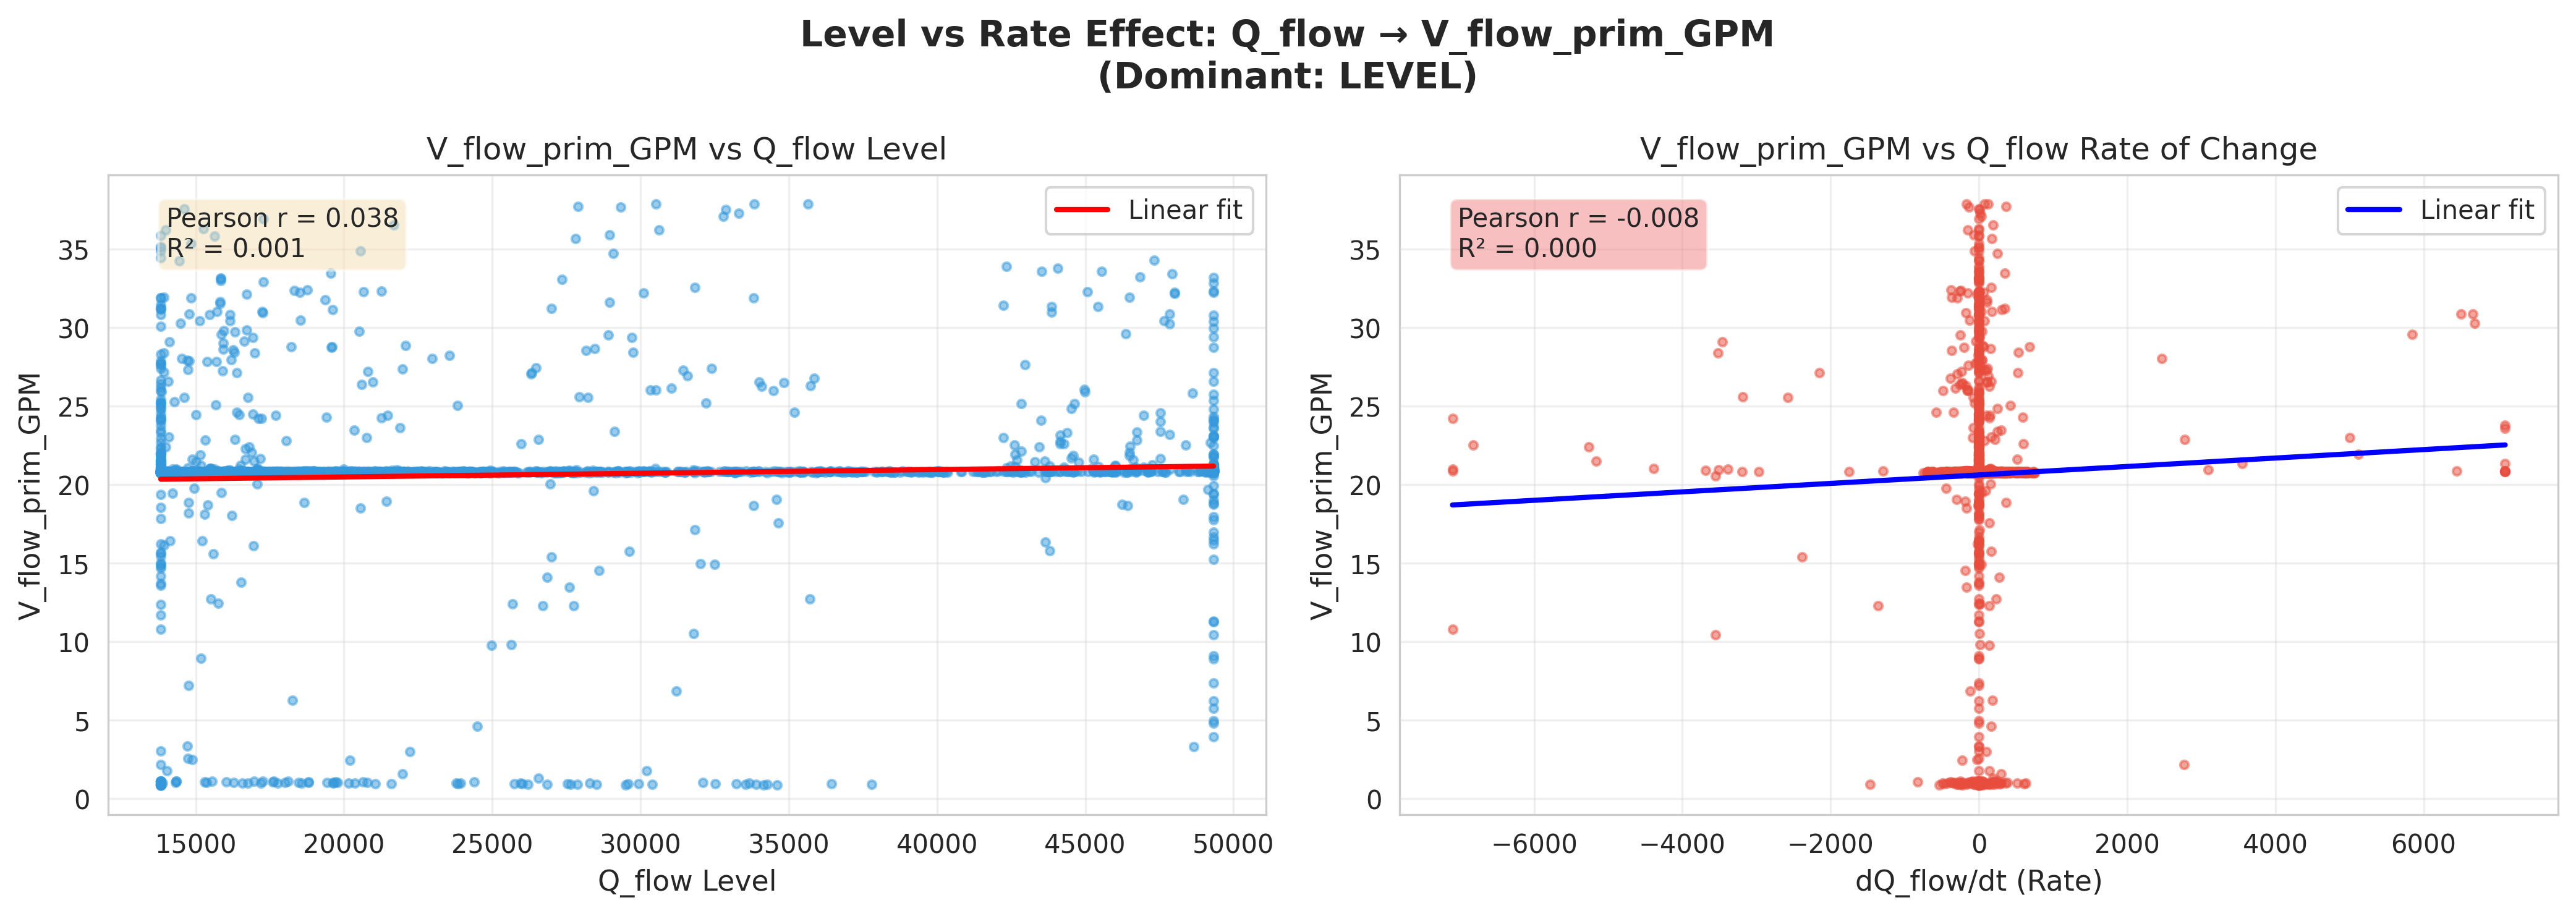

In [22]:
Image(filename=os.path.join(viz_dir, 'rate_comparison_Q_flow_V_flow_prim_GPM.png'))


2026-01-30 11:22:51 - fmu2ml.analysis.rate_of_change.visualizers.level_rate_bar_visualizer - INFO - Creating level vs rate correlation bar charts...
2026-01-30 11:22:51 - matplotlib.text - WARNING - posx and posy should be finite values
2026-01-30 11:22:51 - matplotlib.text - WARNING - posx and posy should be finite values
2026-01-30 11:22:52 - matplotlib.text - WARNING - posx and posy should be finite values
2026-01-30 11:22:52 - matplotlib.text - WARNING - posx and posy should be finite values
2026-01-30 11:22:53 - matplotlib.text - WARNING - posx and posy should be finite values
2026-01-30 11:22:53 - matplotlib.text - WARNING - posx and posy should be finite values
2026-01-30 11:22:54 - matplotlib.text - WARNING - posx and posy should be finite values
2026-01-30 11:22:54 - matplotlib.text - WARNING - posx and posy should be finite values
2026-01-30 11:22:55 - matplotlib.text - WARNING - posx and posy should be finite values
2026-01-30 11:22:57 - fmu2ml.analysis.rate_of_change.visual

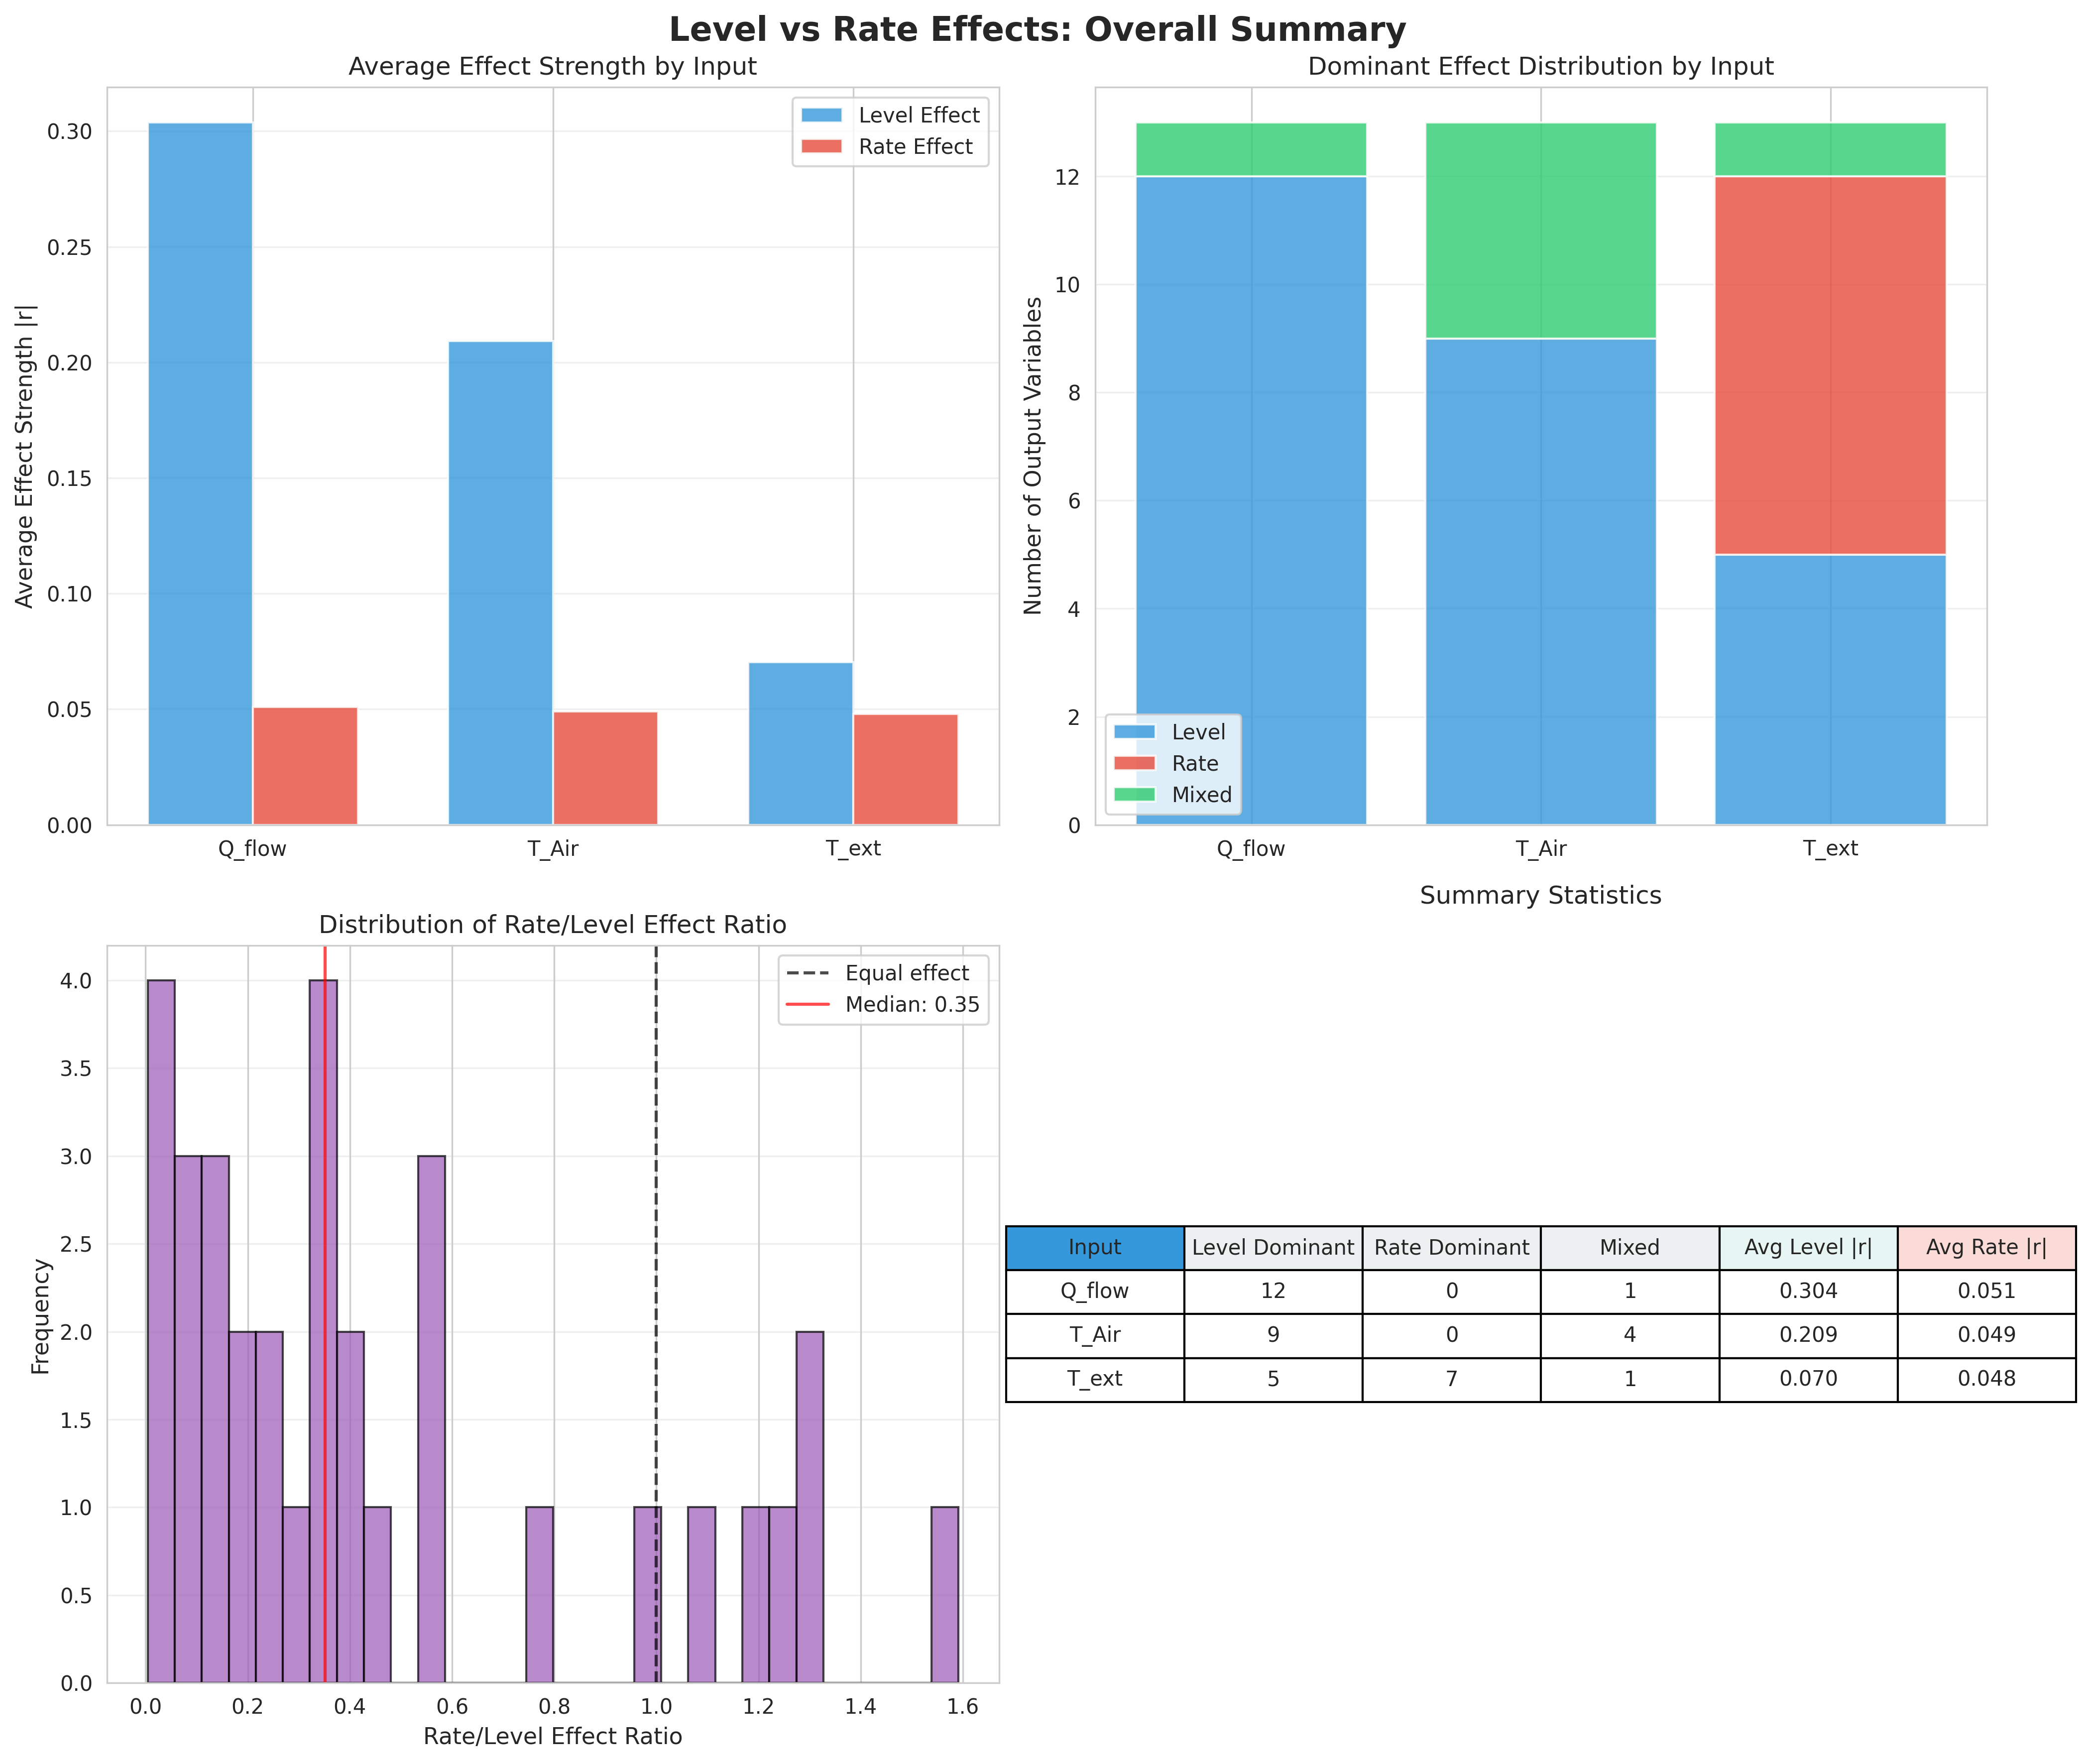

In [23]:

# Visualizations - Correlation Bars
create_level_rate_correlation_bars(level_rate_df, viz_dir)
Image(filename=os.path.join(viz_dir, 'level_rate_overall_summary.png'))


In [ ]:

# Visualizations - Time Series Overlays
if not step_events:
    print("Creating time series overlay plots...")
    create_time_series_overlay_plots(
        prepared_data,
        derivatives_data,
        step_events,
        viz_dir
    )
    
    # Display example
    overlay_plots = [f for f in os.listdir(viz_dir) if f.startswith('time_series_')]
    
Image(filename=os.path.join(viz_dir, 'time_series_overlay_Q_flow.png'))


In [ ]:

# Visualizations - Impulse Responses
if not response_df.empty:
    response_curves = impulse_analyzer.get_response_curves()
    
    print("Creating impulse response plots...")
    create_impulse_response_plots(
        response_curves,
        response_df,
        viz_dir,
        n_workers=N_WORKERS,
        max_plots=50
    )
    
    # Display example
    impulse_plots = [f for f in os.listdir(viz_dir) if f.startswith('impulse_response_')]
    if impulse_plots:
        Image(filename=os.path.join(viz_dir, impulse_plots[0]))


In [ ]:
Image(filename=os.path.join(viz_dir, impulse_plots[0]))


In [ ]:
if not response_summary_df.empty:
    print("Creating response characteristics heatmap...")
    create_response_characteristics_heatmap(response_summary_df, viz_dir)
    Image(filename=os.path.join(viz_dir, 'response_characteristics_heatmap.png'))


In [ ]:
Image(filename=os.path.join(viz_dir,'response_characteristics_heatmap.png'))

## Summary

In [ ]:

#  Analysis Summary - Effect Dominance
print("="*60)
print("LEVEL VS RATE EFFECT SUMMARY")
print("="*60)

# Overall statistics
print(f"\nOverall Effect Distribution:")
for effect_type, count in level_rate_df['dominant_effect'].value_counts().items():
    pct = count / len(level_rate_df) * 100
    print(f"  {effect_type.capitalize()}: {count} ({pct:.1f}%)")

# By input
print("\nBy Input Variable:")
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    input_data = level_rate_df[level_rate_df['input'] == input_var]
    rate_dominant_pct = (input_data['dominant_effect'] == 'rate').sum() / len(input_data) * 100
    print(f"  {input_var}: {rate_dominant_pct:.1f}% rate-dominant")


In [ ]:
# Analysis Summary - Response Dynamics
print("="*60)
print("RESPONSE DYNAMICS SUMMARY")
print("="*60)

print("\nResponse Lag Characteristics:")
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    input_lags = lag_df[lag_df['input'] == input_var]
    print(f"\n  {input_var}:")
    print(f"    Mean lag: {input_lags['optimal_lag'].mean():.1f} steps")
    print(f"    Median lag: {input_lags['optimal_lag'].median():.1f} steps")
    print(f"    Max lag: {input_lags['optimal_lag'].max():.0f} steps")
    print(f"    Mean correlation: {input_lags['max_correlation'].mean():.3f}")


In [ ]:

# Analysis Summary - Impulse Response
if not response_summary_df.empty:
    print("="*60)
    print("IMPULSE RESPONSE SUMMARY")
    print("="*60)
    
    for input_var in response_summary_df['input'].unique():
        input_summary = response_summary_df[response_summary_df['input'] == input_var]
        
        print(f"\n{input_var} Impulse Characteristics:")
        print(f"  Output-input pairs: {len(input_summary)}")
        print(f"  Avg rise time: {input_summary['rise_time_mean'].mean():.1f} steps")
        print(f"  Avg settling time: {input_summary['settling_time_mean'].mean():.1f} steps")
        print(f"  Avg gain: {input_summary['gain_mean'].mean():.4f}")
        print(f"  Avg time constant: {input_summary['time_constant_mean'].mean():.1f} steps")


In [ ]:

# Modeling Recommendations
print("="*60)
print("MODELING RECOMMENDATIONS")
print("="*60)

# Check rate importance
rate_important = (level_rate_df['dominant_effect'] == 'rate').sum() / len(level_rate_df)

print("\n1. Derivative Features:")
if rate_important > 0.3:
    print("   ✓ HIGH IMPORTANCE: Include rate-of-change features")
    print(f"     {rate_important*100:.1f}% of relationships are rate-dominant")
elif rate_important > 0.1:
    print("   ⚠ MODERATE IMPORTANCE: Consider including rate features")
else:
    print("   ✗ LOW IMPORTANCE: Level features may be sufficient")

# Check temporal dependencies
avg_lag = lag_df['optimal_lag'].mean()
max_lag = lag_df['optimal_lag'].max()

print("\n2. Temporal Dependencies:")
if avg_lag > 10:
    print(f"   ✓ STRONG: Use RNN/LSTM (avg lag = {avg_lag:.1f} steps)")
elif avg_lag > 5:
    print(f"   ⚠ MODERATE: Consider sequence models or lagged features")
else:
    print(f"   ✗ WEAK: Feedforward network may suffice")

# Check response characteristics
if not response_summary_df.empty:
    avg_time_const = response_summary_df['time_constant_mean'].mean()
    print("\n3. System Dynamics:")
    print(f"   Average time constant: {avg_time_const:.1f} steps")
    if avg_time_const > 20:
        print("   → Slow dynamics: Long sequence length needed")
    elif avg_time_const > 10:
        print("   → Moderate dynamics: Medium sequence length")
    else:
        print("   → Fast dynamics: Short sequence may work")


## Save Results 

In [ ]:

# Save All Results
print("Saving results...")

# Save dataframes
level_rate_df.to_csv(os.path.join(OUTPUT_DIR, 'level_rate_metrics.csv'), index=False)
lag_df.to_csv(os.path.join(OUTPUT_DIR, 'lag_analysis.csv'), index=False)

if not response_df.empty:
    response_df.to_csv(os.path.join(OUTPUT_DIR, 'impulse_responses.csv'), index=False)
    response_summary_df.to_csv(os.path.join(OUTPUT_DIR, 'response_summary.csv'), index=False)

if 'dynamics_summary' in locals():
    dynamics_summary.to_csv(os.path.join(OUTPUT_DIR, 'dynamics_summary.csv'), index=False)

print(f"\nAll results saved to: {OUTPUT_DIR}")
print("\nFiles created:")
print("  - dynamic_data.parquet")
print("  - level_rate_metrics.csv")
print("  - lag_analysis.csv")
print("  - impulse_responses.csv")
print("  - response_summary.csv")
print("  - dynamics_summary.csv")
print("  - visualizations/ (multiple plots)")


In [ ]:

# Cleanup
rate_analyzer._close_dask_client()
impulse_analyzer._close_dask_client()

print("\nAnalysis complete! Dask clients closed.")